In [2]:
import os
import glob
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# ==========================================
# BƯỚC 1: ĐỌC, LẤY MẪU (SAMPLING) VÀ GỘP DỮ LIỆU
# ==========================================
# Đường dẫn đến thư mục chứa các file đã làm sạch của bạn
folder_path = '../data/csv-01-12/training/scaled/scaled/scaled/' 

# Tìm tất cả các file có đuôi .csv
all_files = glob.glob(os.path.join(folder_path, "*.csv"))

df_list = []

# Số lượng mẫu muốn lấy cho MỖI FILE (Theo kế hoạch dự án là 20.000)
SAMPLES_PER_FILE = 20000 

print(f"Đang nạp và lấy mẫu tối đa {SAMPLES_PER_FILE} dòng từ mỗi file...")
print("-" * 50)

for file in all_files:
    file_name = os.path.basename(file)
    
    # Đọc file hiện tại
    temp_df = pd.read_csv(file)
    total_rows = len(temp_df)
    
    # Tránh lỗi nếu file có số dòng ít hơn SAMPLES_PER_FILE
    n_samples = min(SAMPLES_PER_FILE, total_rows)
    
    # THUẬT TOÁN SAMPLING CHO TIME-SERIES:
    # 1. Lấy ngẫu nhiên n_samples dòng (random_state để kết quả luôn giống nhau ở các lần chạy)
    # 2. .sort_index() để đưa các dòng được chọn về lại đúng thứ tự thời gian ban đầu
    sampled_df = temp_df.sample(n=n_samples, random_state=42).sort_index()
    
    print(f" -> {file_name}: Lấy {n_samples:,} / {total_rows:,} dòng")
    df_list.append(sampled_df)

# Gộp tất cả các DataFrame trong danh sách thành một DataFrame duy nhất
df = pd.concat(df_list, ignore_index=True)

print("-" * 50)
print(f" HOÀN TẤT GỘP DỮ LIỆU!")
print(f" Tổng số dòng đưa vào huấn luyện: {df.shape[0]:,}")
print(f" Tổng số cột (Đặc trưng + Nhãn): {df.shape[1]}")
print("-" * 50)

# Tách đặc trưng và nhãn
X = df.drop(columns=['Label'])
y = df['Label']

# Chuẩn hóa dữ liệu về cùng thang đo (0 - 1)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Mã hóa nhãn văn bản sang số
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

# => SAU ĐÓ BẠN TIẾP TỤC VỚI BƯỚC 2 (create_sequences) NHƯ CODE CŨ NHÉ!

Đang nạp và lấy mẫu tối đa 20000 dòng từ mỗi file...
--------------------------------------------------
 -> LSTM_DrDos_DNS_scaled.csv: Lấy 7,731 / 7,731 dòng
 -> LSTM_DrDos_LDAP_scaled.csv: Lấy 4,030 / 4,030 dòng
 -> LSTM_DrDos_MSSQL_scaled.csv: Lấy 5,015 / 5,015 dòng
 -> LSTM_DrDos_NetBIOS_scaled.csv: Lấy 4,267 / 4,267 dòng
 -> LSTM_DrDos_NTP_scaled.csv: Lấy 20,000 / 35,913 dòng
 -> LSTM_DrDos_SNMP_scaled.csv: Lấy 3,348 / 3,348 dòng
 -> LSTM_DrDos_SSDP_scaled.csv: Lấy 1,696 / 1,696 dòng
 -> LSTM_DrDos_UDP_scaled.csv: Lấy 5,392 / 5,392 dòng
 -> LSTM_Syn_scaled.csv: Lấy 981 / 981 dòng
 -> LSTM_TFTP_scaled.csv: Lấy 20,000 / 63,118 dòng
 -> LSTM_UDPLag_scaled.csv: Lấy 9,263 / 9,263 dòng
--------------------------------------------------
 HOÀN TẤT GỘP DỮ LIỆU!
 Tổng số dòng đưa vào huấn luyện: 81,723
 Tổng số cột (Đặc trưng + Nhãn): 26
--------------------------------------------------


Đang tạo các chuỗi thời gian (Time-Series Sequences)...
Kích thước X sau biến đổi (Mẫu, Time-steps, Đặc trưng): (81713, 10, 25)
Kích thước y sau biến đổi: (81713,)
Tập Huấn luyện: 65370 mẫu
Tập Kiểm thử: 16343 mẫu
--------------------------------------------------
Đang khởi tạo mô hình LSTM Đa lớp...


C:\Users\Admin\miniconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 10, 64)              │          23,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 64)                  │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 56,194 (219.51 KB)

 Trainable params: 56,194 (219.51 KB)

 Non-trainable params: 0 (0.00 B)


Bắt đầu huấn luyện...
Epoch 1/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.7431 - loss: 0.5397 - val_accuracy: 0.7549 - val_loss: 0.5431 - learning_rate: 0.0010
Epoch 2/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.7627 - loss: 0.5117 - val_accuracy: 0.7485 - val_loss: 0.5484 - learning_rate: 0.0010
Epoch 3/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7837 - loss: 0.4855 - val_accuracy: 0.7258 - val_loss: 0.5944 - learning_rate: 0.0010
Epoch 4/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.7977 - loss: 0.4602 - val_accuracy: 0.7500 - val_loss: 0.5370 - learning_rate: 0.0010
Epoch 5/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.8192 - loss: 0.4285 - val_accuracy: 0.7635 - val_loss: 0.5118 - learning_rate: 0.0010
Epoch 6/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.8292 - loss: 0.4091 - val_accuracy: 0.7518 - val_loss: 0.5356 - learning_rate: 0.0010
Epoch 7/50
256/256 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step 

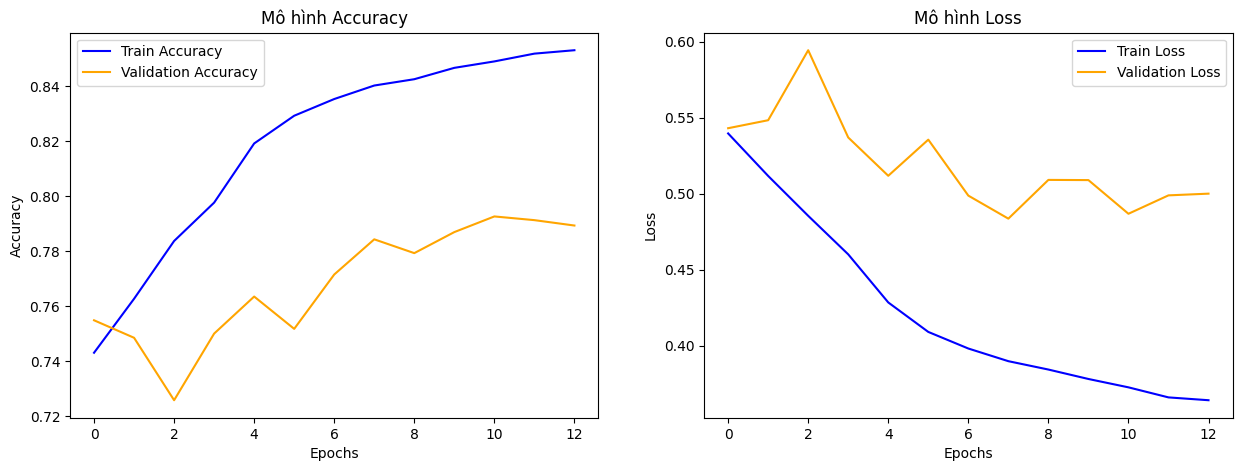

511/511 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step

BÁO CÁO ĐÁNH GIÁ MÔ HÌNH (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

           0       0.76      0.90      0.82      9174
           1       0.84      0.63      0.72      7169

    accuracy                           0.78     16343
   macro avg       0.80      0.77      0.77     16343
weighted avg       0.79      0.78      0.78     16343



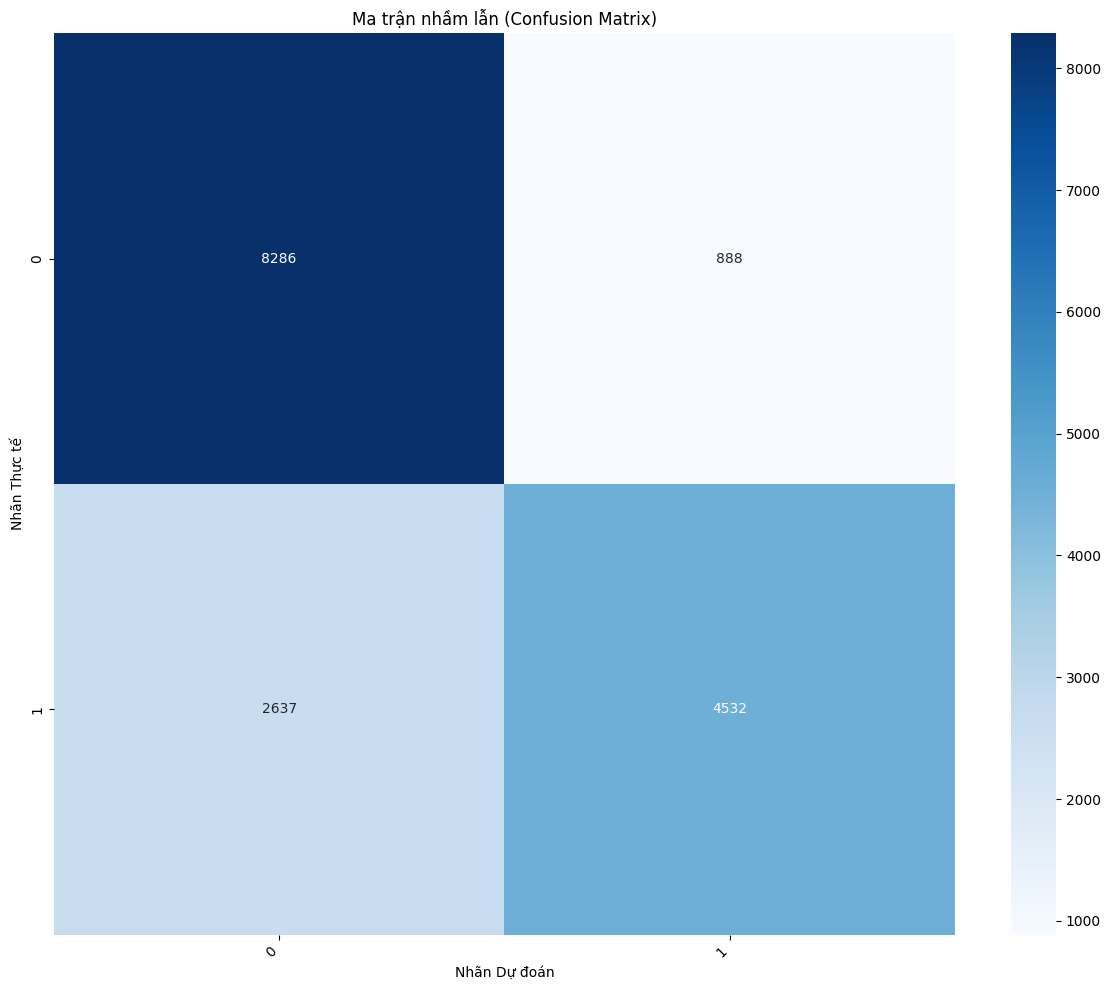

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# BƯỚC 2: CHUYỂN ĐỔI SANG DẠNG TIME-SERIES (SLIDING WINDOW)
# ==========================================
print("Đang tạo các chuỗi thời gian (Time-Series Sequences)...")

def create_sequences(X_data, y_data, time_steps):
    X_seq, y_seq = [], []
    # Khung cửa sổ trượt (sliding window) dọc theo dữ liệu
    for i in range(len(X_data) - time_steps):
        X_seq.append(X_data[i : i + time_steps])
        y_seq.append(y_data[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

# Khai báo số bước thời gian (Ví dụ: Gom 10 gói tin liên tiếp thành 1 chuỗi hành vi)
TIME_STEPS = 10 
X_ts, y_ts = create_sequences(X_scaled, y_encoded, TIME_STEPS)

print(f"Kích thước X sau biến đổi (Mẫu, Time-steps, Đặc trưng): {X_ts.shape}")
print(f"Kích thước y sau biến đổi: {y_ts.shape}")

# Chia tập Train/Test
# LƯU Ý QUAN TRỌNG: shuffle=False để không làm xáo trộn trật tự thời gian
X_train, X_test, y_train, y_test = train_test_split(X_ts, y_ts, test_size=0.2, random_state=42, shuffle=False)

print(f"Tập Huấn luyện: {X_train.shape[0]} mẫu")
print(f"Tập Kiểm thử: {X_test.shape[0]} mẫu")
print("-" * 50)

# ==========================================
# BƯỚC 3: XÂY DỰNG MÔ HÌNH LSTM TIME-SERIES
# ==========================================
print("Đang khởi tạo mô hình LSTM Đa lớp...")
model = Sequential()

# Lớp LSTM thứ nhất (Nhận đầu vào là chuỗi 3 chiều)
model.add(LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

# Lớp LSTM thứ hai
model.add(LSTM(units=64, return_sequences=False))
model.add(Dropout(0.2))

# Lớp Output (Đầu ra bằng số lượng lớp nhãn: 12 lớp)
num_classes = len(np.unique(y_encoded))
model.add(Dense(units=num_classes, activation='softmax'))

# Biên dịch mô hình
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# ==========================================
# BƯỚC 4: HUẤN LUYỆN MÔ HÌNH
# ==========================================
# Tối ưu hóa việc huấn luyện
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)

print("\nBắt đầu huấn luyện...")
history = model.fit(
    X_train, y_train,
    epochs=50,                # Có thể điều chỉnh số lượng Epochs
    batch_size=256,           # Xử lý 256 chuỗi mỗi lần cập nhật trọng số
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

# Lưu mô hình theo định dạng hiện đại
model.save('DDoS_LSTM_TimeSeries_Model.keras')
print("Đã lưu mô hình thành công: DDoS_LSTM_TimeSeries_Model.keras")

# ==========================================
# BƯỚC 5: ĐÁNH GIÁ (TRỰC QUAN HÓA)
# ==========================================
# 1. Vẽ biểu đồ Lịch sử hội tụ (Loss & Accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Biểu đồ Accuracy
ax1.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Mô hình Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Biểu đồ Loss
ax2.plot(history.history['loss'], label='Train Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Mô hình Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
plt.show()

# =========================================
# Dự đoán trên tập Test
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# Lấy lại tên nhãn gốc từ LabelEncoder (ví dụ: 'UDPLag', 'Syn', 'Normal'...)
target_names = [str(label) for label in encoder.classes_]

# 2. Báo cáo đánh giá chi tiết
print("\n" + "="*50)
print("BÁO CÁO ĐÁNH GIÁ MÔ HÌNH (CLASSIFICATION REPORT)")
print("="*50)
print(classification_report(y_test, y_pred_classes, target_names=target_names))

# 3. Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Ma trận nhầm lẫn (Confusion Matrix)')
plt.ylabel('Nhãn Thực tế')
plt.xlabel('Nhãn Dự đoán')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()